In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Social_Network_Ads.csv')

In [5]:
df.shape

(400, 3)

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
391,47,23000,1
285,37,93000,1
113,37,55000,0
270,43,133000,0
392,45,45000,1


In [11]:
%pip install scikit-learn 

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 5.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 10.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 10.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 8.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 7.2 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.0 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
    --------------------------------------- 0.8/37.4 MB 4.3 MB/s eta 0:00:09
   - -------------------------------------- 1.6/37.4 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/37.4 MB 4.3 M

#TRAIN TEST SPLIT

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('Purchased',axis=1),
                                                 df['Purchased'],
                                                 test_size=0.3,
                                                 random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit the scaler to the train set, it will leran the parameter
scaler.fit(X_train)

#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [24]:
X_train_scaled = pd.DataFrame(X_train_scaled,column = X_train.column)
X_test_scaled - pd.DataFrame(X_test_scaled,column = X_test.column)

In [25]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


#Effect of scaling

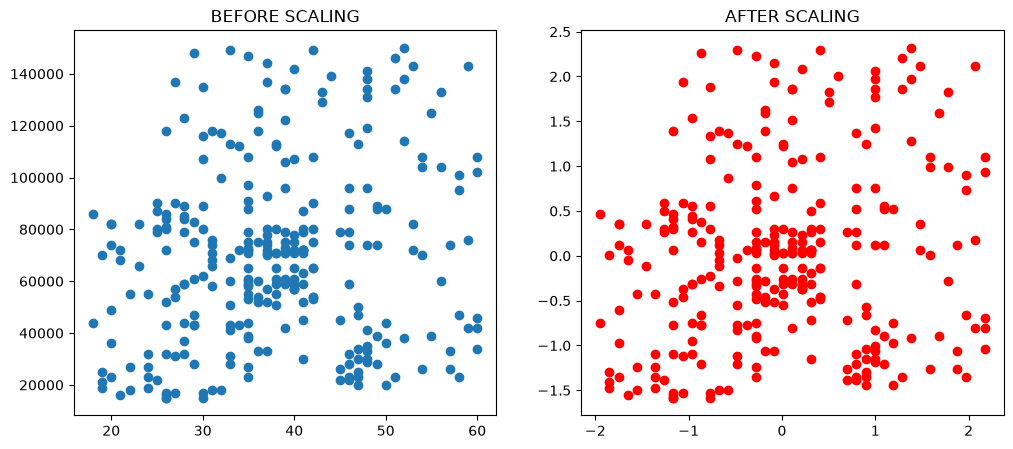

In [27]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("BEFORE SCALING")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color = 'red')
ax2.set_title("AFTER SCALING")
plt.show()